# aDOGme — Modelo de Predicción + Cálculo de Compatibilidad

**Modelo multi-clase** que predice AdoptionSpeed (0,1,2,3,4)

**20 preguntas** (4 categorías × 5) → vector de 4 dimensiones

**Compatibilidad** = α × similitud (distancia euclidiana) + β × ML (predict_proba)



### Celda 1: Imports


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
)
from sklearn.preprocessing import label_binarize
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print(" Imports listos")

 Imports listos


### Cargando data


In [6]:

train = pd.read_csv('train.csv')
print(f"Dataset: {train.shape[0]} registros, {train.shape[1]} columnas")
print(f"Tipos: Dog={( train['Type']==1).sum()}, Cat={(train['Type']==2).sum()}")

Dataset: 14993 registros, 24 columnas
Tipos: Dog=8132, Cat=6861


### Nuestro dataset contiene 2 tipos de animales, type 1 = dogs, type 2 = cats, para nuestro caso filtramos dogs


In [7]:
dogs = train[train['Type'] == 1].copy()
print(f"Total perros: {len(dogs)}")

##here is where the replacement occurs. We are combining the first two classes into a single class
## to increase accuracy, since classes are imbalanced.
dogs['AdoptionSpeed'] = dogs['AdoptionSpeed'].replace({0: 0, 1: 0, 2: 1, 3: 2, 4: 3})

speed_labels = {0: "Primeros 7 dias", 1: "8-30 dias",
                2: "31-90 dias", 3: "No adoptado"}

colors_speed = ['#2ecc71', '#ffd93d', '#ff6b6b', '#c0392b']

print(f"\nDistribucion de AdoptionSpeed (4 clases):")
for speed, count in dogs['AdoptionSpeed'].value_counts().sort_index().items():
    bar = "█" * (count // 50)
    pct = count / len(dogs) * 100
    print(f"  {speed} ({speed_labels[speed]:15s}): {count:5d} ({pct:.1f}%) {bar}")

Total perros: 8132

Distribucion de AdoptionSpeed (4 clases):
  0 (Primeros 7 dias):  1605 (19.7%) ████████████████████████████████
  1 (8-30 dias      ):  2164 (26.6%) ███████████████████████████████████████████
  2 (31-90 dias     ):  1949 (24.0%) ██████████████████████████████████████
  3 (No adoptado    ):  2414 (29.7%) ████████████████████████████████████████████████


### Celda 4: Visualizar distribución


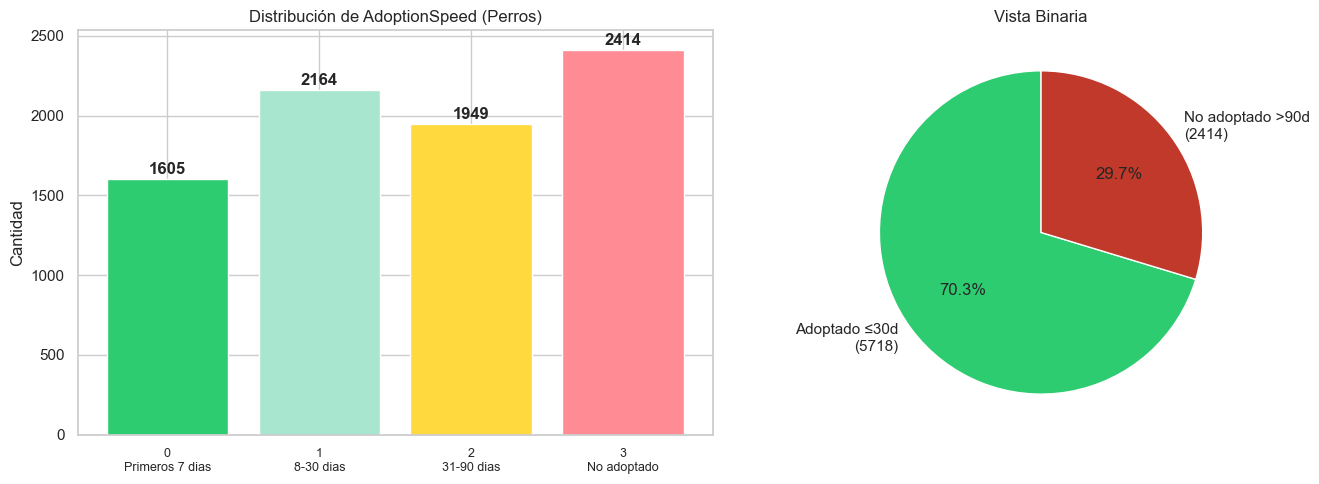

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_speed = ['#2ecc71', '#a8e6cf', '#ffd93d', '#ff8b94', '#c0392b']
counts = dogs['AdoptionSpeed'].value_counts().sort_index()

bars = axes[0].bar(range(4), counts.values, color=colors_speed)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([f"{k}\n{v}" for k, v in speed_labels.items()], fontsize=9)
axes[0].set_ylabel('Cantidad')
axes[0].set_title('Distribución de AdoptionSpeed (Perros)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}', ha='center', fontweight='bold')

adopted = (dogs['AdoptionSpeed'] <= 2).sum()
not_adopted = (dogs['AdoptionSpeed'] > 2).sum()
axes[1].pie([adopted, not_adopted],
            labels=[f'Adoptado ≤30d\n({adopted})', f'No adoptado >90d\n({not_adopted})'],
            autopct='%1.1f%%', colors=['#2ecc71', '#c0392b'], startangle=90)
axes[1].set_title('Vista Binaria')

plt.tight_layout()
plt.show()

Empezamos con el analisis EDA por feature:
Estas son nuestras features
PetID - Unique hash ID of pet profile
AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
Type - Type of animal (1 = Dog, 2 = Cat)
Name - Name of pet (Empty if not named)
Age - Age of pet when listed, in months
Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
Quantity - Number of pets represented in profile
Fee - Adoption fee (0 = Free)
State - State location in Malaysia (Refer to StateLabels dictionary)
RescuerID - Unique hash ID of rescuer
VideoAmt - Total uploaded videos for this pet
PhotoAmt - Total uploaded photos for this pet
Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

Analizando Age: Perros mas jovenes en el dataset

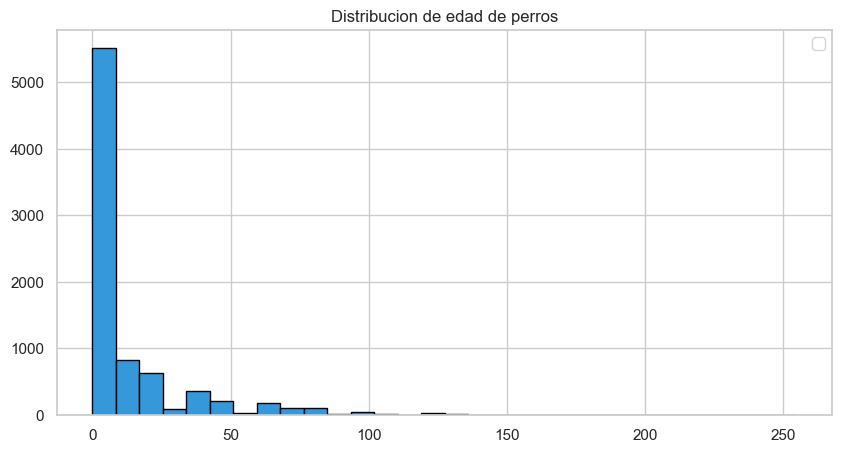

In [11]:
fig,ax = plt.subplots(figsize=(10,5))
plt.title('Distribucion de edad de perros')
dogs['Age'].hist(bins=30, color='#3498db', edgecolor='black')
plt.legend()

Grafica de violin, viendo cantidad de datos por adoptionSpeed y numero de perros.

<Axes: xlabel='AdoptionSpeed', ylabel='Age'>

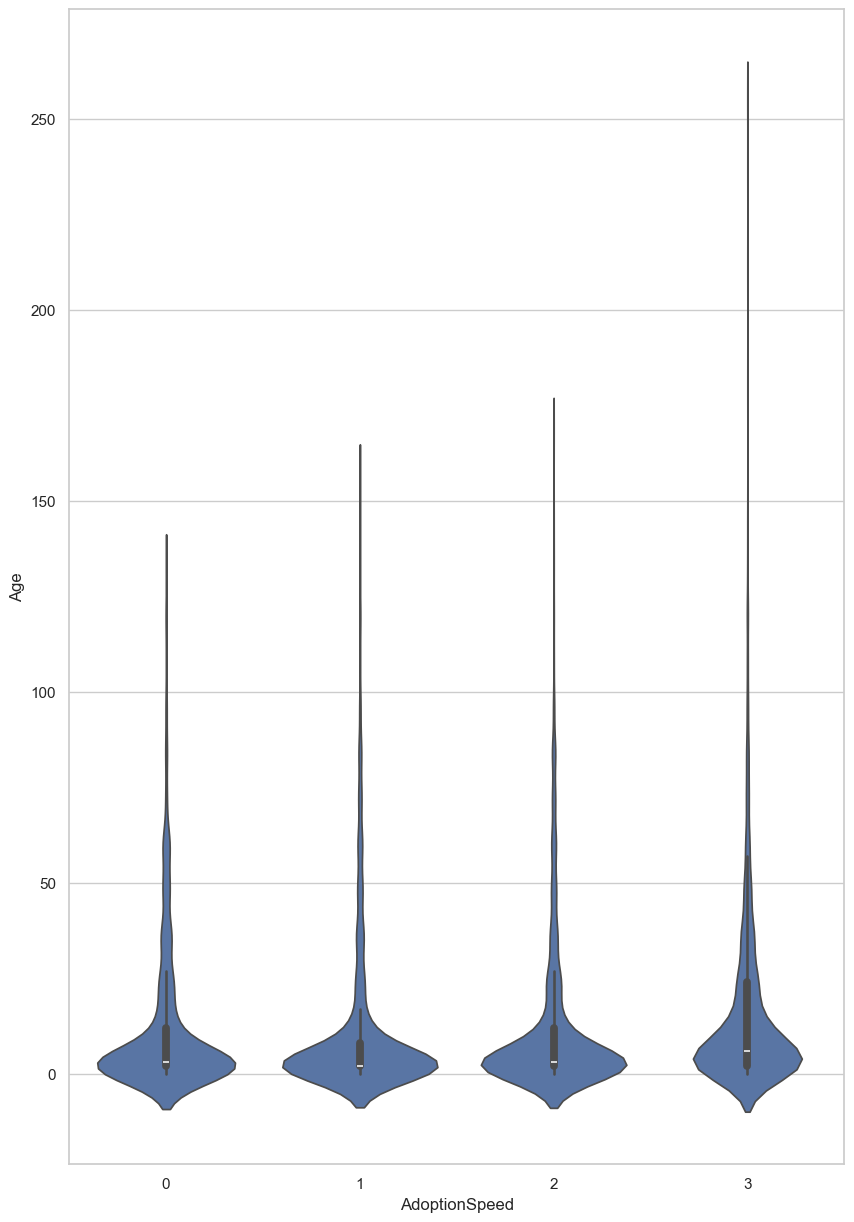

In [12]:
plt.figure(figsize=(10,15))
sns.violinplot(x='AdoptionSpeed',y='Age',data=dogs)

In [13]:
##AdoptionSpeed trend by age
import plotly.graph_objects as go
import plotly.offline as py
data = []
for a in range(4):
    ##filtramos por cada clase de AdoptionSpeed
    df = dogs.loc[dogs['AdoptionSpeed'] == a]

##y graficamos la cantidad de perros por edad para cada clase de AdoptionSpeed  
    data.append(go.Scatter(x =df['Age'].value_counts().sort_index().index,
                          y = df['Age'].value_counts().sort_index().values,
                          name = str(a)))
##configuramos la grafica
fig = go.Layout(dict(title = 'AdoptionSpeed trend by age',
                     xaxis = dict(title = 'Age'),
                     yaxis = dict(title = 'Count'),
                     width=3200),
                     height=800)
##mostramos la grafica
py.iplot(dict(data=data,layout=fig),filename='AdoptionSpeed trend by age')

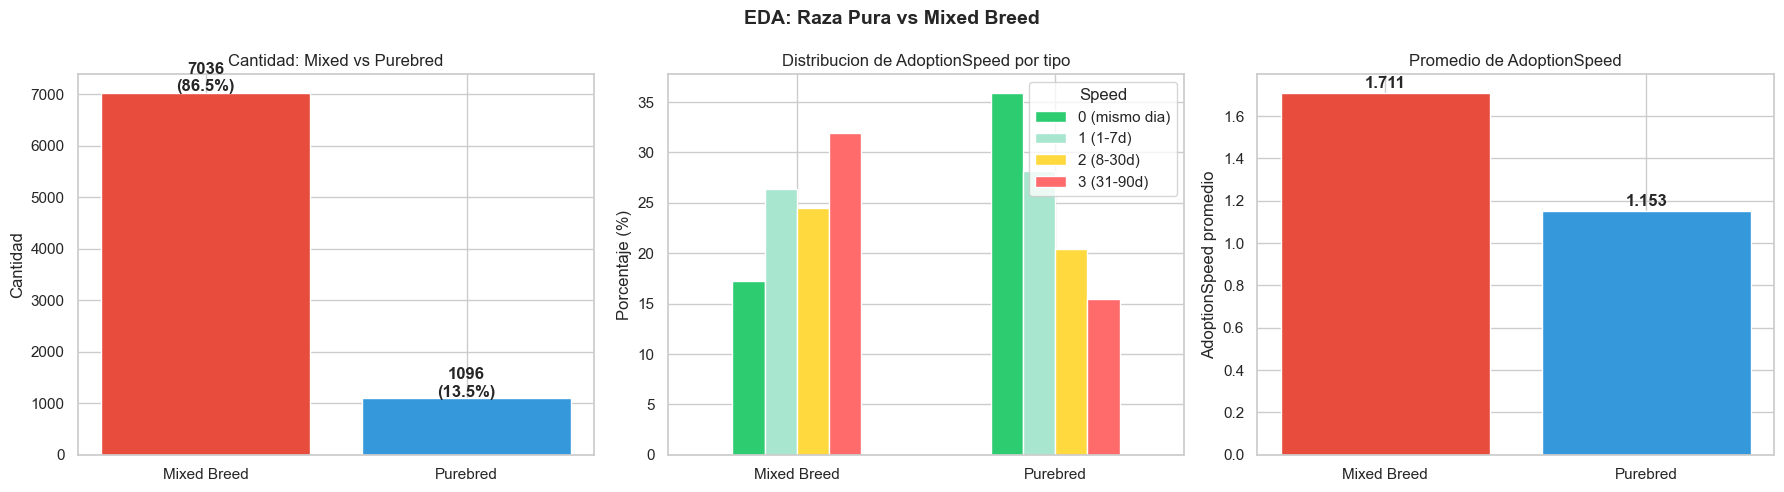

Promedio AdoptionSpeed Mixed:    1.711
Promedio AdoptionSpeed Purebred: 1.153
Diferencia: 0.558


In [14]:
# --- EDA: Raza Pura vs Mixed Breed y AdoptionSpeed ---


is_mixed = ((dogs['Breed2'] != 0) | (dogs['Breed1'] == 307) | (dogs['Breed2'] == 307))
dogs['_breed_type'] = is_mixed.map({True: 'Mixed Breed', False: 'Purebred'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Conteo total: Mixed vs Purebred
breed_counts = dogs['_breed_type'].value_counts()
axes[0].bar(breed_counts.index, breed_counts.values, color=['#e74c3c', '#3498db'])
axes[0].set_title('Cantidad: Mixed vs Purebred')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(breed_counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(dogs)*100:.1f}%)', ha='center', fontweight='bold')

# Distribucion de AdoptionSpeed por tipo de raza (proporciones)
speed_by_breed = dogs.groupby(['_breed_type', 'AdoptionSpeed']).size().unstack(fill_value=0)
speed_by_breed_pct = speed_by_breed.div(speed_by_breed.sum(axis=1), axis=0) * 100

colors_speed = ['#2ecc71', '#a8e6cf', '#ffd93d', '#ff6b6b', '#c0392b']
speed_by_breed_pct.plot(kind='bar', ax=axes[1], color=colors_speed, edgecolor='white')
axes[1].set_title('Distribucion de AdoptionSpeed por tipo')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Speed', labels=['0 (mismo dia)', '1 (1-7d)', '2 (8-30d)', '3 (31-90d)', '4 (no adoptado)'])

# Promedio de AdoptionSpeed por tipo
avg_speed = dogs.groupby('_breed_type')['AdoptionSpeed'].mean()
axes[2].bar(avg_speed.index, avg_speed.values, color=['#e74c3c', '#3498db'])
axes[2].set_title('Promedio de AdoptionSpeed')
axes[2].set_ylabel('AdoptionSpeed promedio')
for i, v in enumerate(avg_speed.values):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('EDA: Raza Pura vs Mixed Breed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print(f"Promedio AdoptionSpeed Mixed:    {avg_speed['Mixed Breed']:.3f}")
print(f"Promedio AdoptionSpeed Purebred: {avg_speed['Purebred']:.3f}")
print(f"Diferencia: {abs(avg_speed['Mixed Breed'] - avg_speed['Purebred']):.3f}")

dogs.drop('_breed_type', axis=1, inplace=True)

Analisis de correlaciones, la correlacion nos dice de que manera se relacionan las features con nuestra clase final. De esta manera podemos seleccionar de manera correcta el modelo que usaremos, si sera un modelo lineal o no lineal, como en este caso que usaremos un modelo basado en arboles ya que no existe una alta correlacion entre las features y la variable objetivo

Columnas numéricas: ['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt', 'AdoptionSpeed', 'is_mixed_breed', 'has_name', 'is_puppy', 'is_free', 'desc_length', 'desc_word_count', 'health_score', 'age_bucket', 'has_photos', 'has_video']


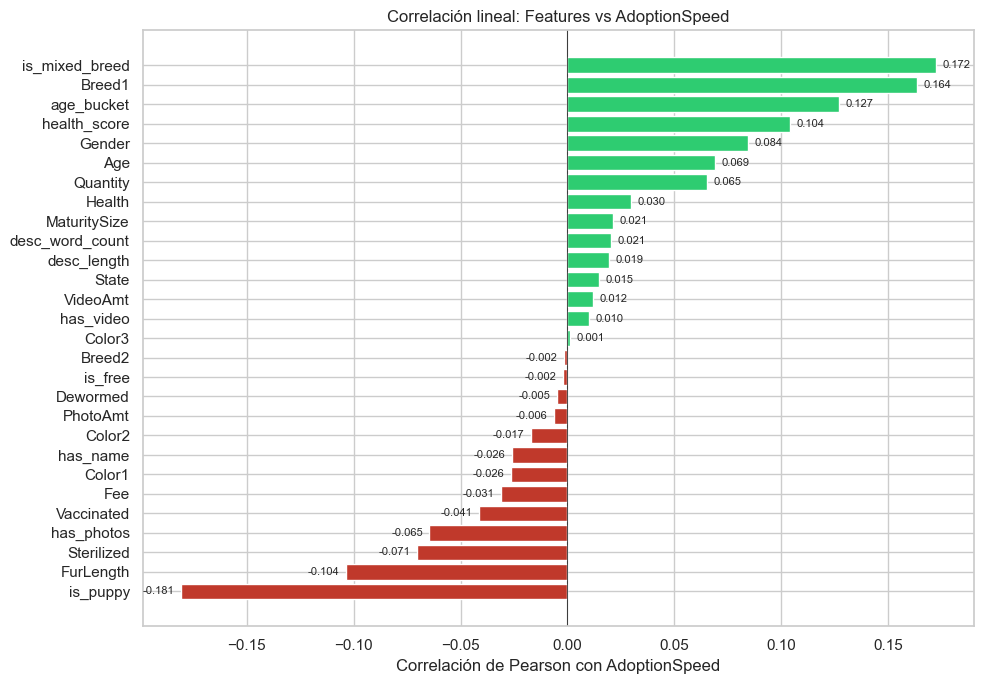

Observaciones:
  - Correlaciones lineales bajas (max 0.17)
  - Esto sugiere relaciones NO lineales → modelos de árboles son apropiados
  - FurLength correlación negativa: pelo corto → adopción más rápida


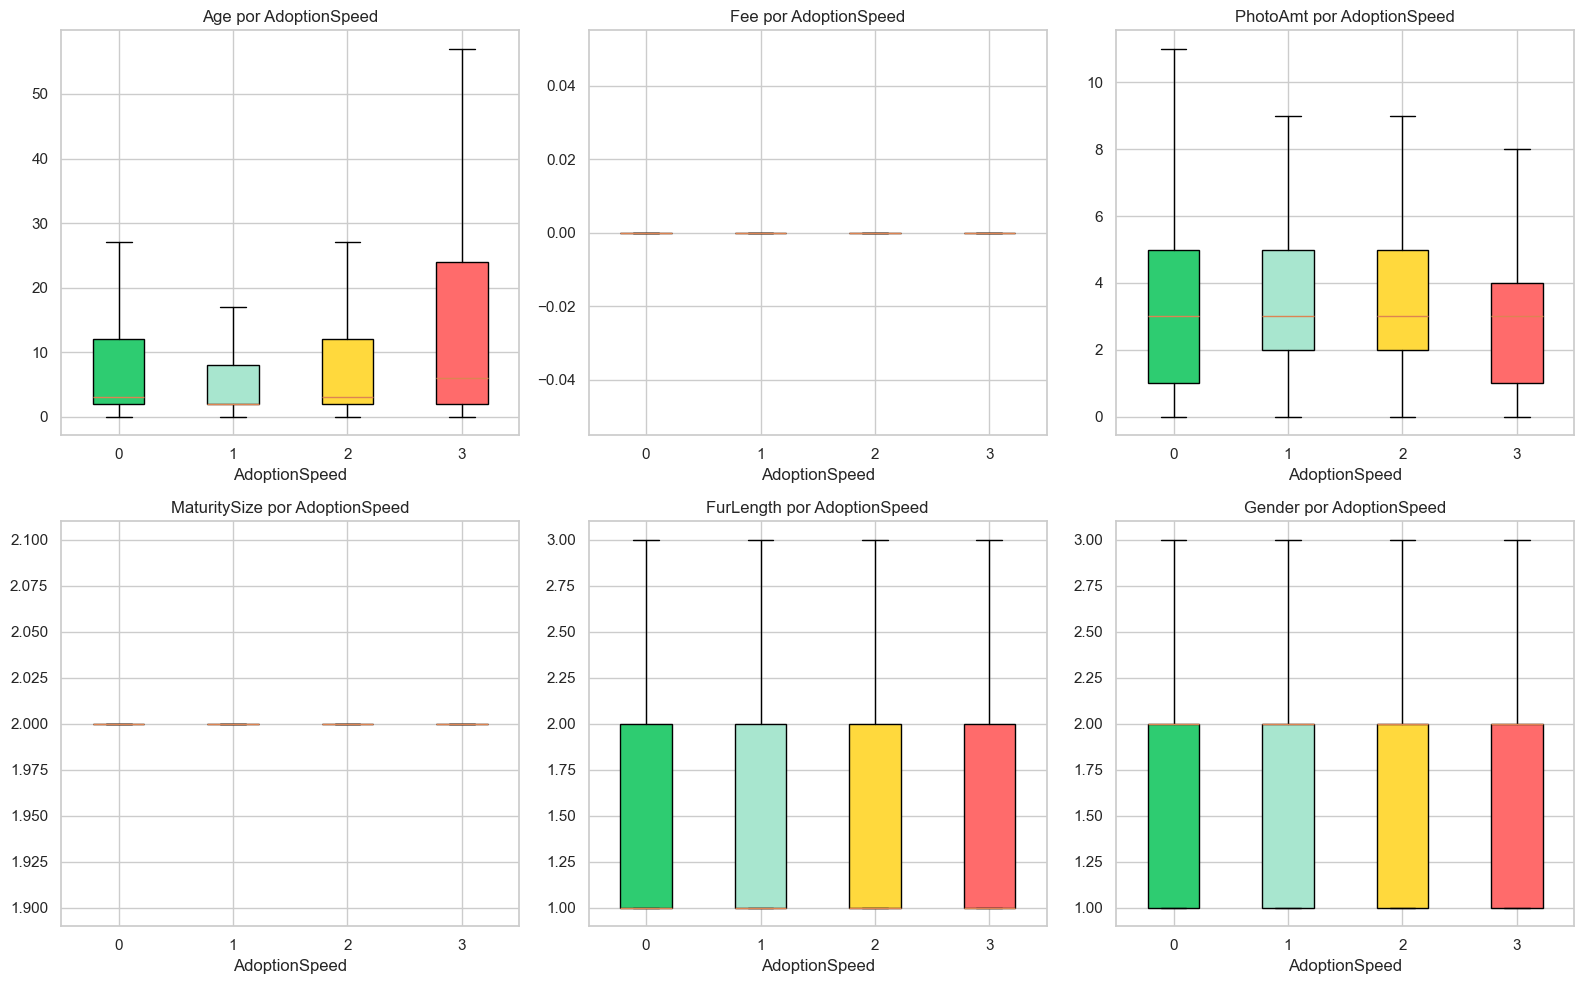

Observaciones:
  - Age: cachorros dominan speed 0-1, adultos mayores en speed 3-4
  - Fee: adopciones rápidas tienden a ser gratuitas
  - MaturitySize: perros pequeños se adoptan ligeramente más rápido


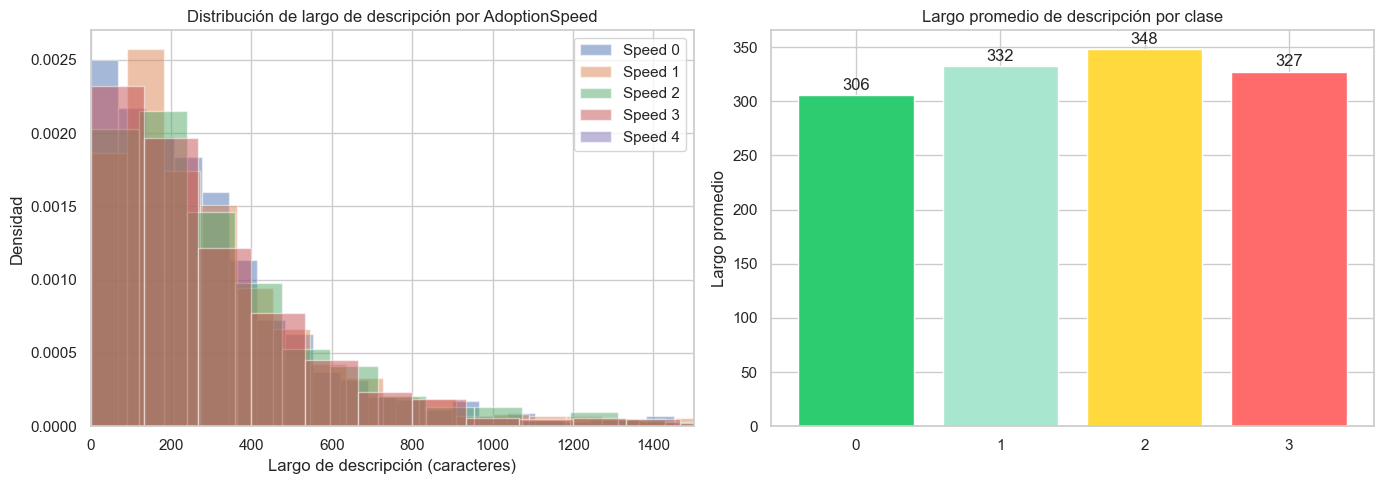

Speed 0 promedio: 306 chars vs Speed 3: 327 chars
→ Descripciones más largas correlacionan con adopción más rápida


In [35]:
# Correlaciones con AdoptionSpeed
numeric_cols = dogs.select_dtypes(include=[np.number]).columns.tolist()
print(f"Columnas numéricas: {numeric_cols}")
for col in ['Type']:
    if col in numeric_cols: numeric_cols.remove(col)

##Obteniendo la correlacion de pearson de cada feature con la variable objetivo AdoptionSpeed, ordenando de menor a mayor y graficando con colores rojo para correlaciones negativas y verde para positivas
corrs = dogs[numeric_cols].corr()['AdoptionSpeed'].drop('AdoptionSpeed').sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_corr = ['#c0392b' if v < 0 else '#2ecc71' for v in corrs.values]
ax.barh(range(len(corrs)), corrs.values, color=colors_corr)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index)
ax.set_xlabel('Correlación de Pearson con AdoptionSpeed')
ax.set_title('Correlación lineal: Features vs AdoptionSpeed')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, v in enumerate(corrs.values):
    ax.text(v + 0.003 if v >= 0 else v - 0.003, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

print("Observaciones:")
print("  - Correlaciones lineales bajas (max 0.17)")
print("  - Esto sugiere relaciones NO lineales → modelos de árboles son apropiados")
print("  - FurLength correlación negativa: pelo corto → adopción más rápida")



fig, axes = plt.subplots(2, 3, figsize=(16, 10))
features_eda = ['Age', 'Fee', 'PhotoAmt', 'MaturitySize', 'FurLength', 'Gender']

##Diagrama de cajas (boxplot) para cada feature vs AdoptionSpeed, con colores por clase de AdoptionSpeed
for ax, feat in zip(axes.flatten(), features_eda):
    data_by_speed = [dogs[dogs['AdoptionSpeed'] == s][feat].values for s in range(4)]
    bp = ax.boxplot(data_by_speed, labels=[str(s) for s in range(4)],
                     patch_artist=True, showfliers=False)
    for patch, color in zip(bp['boxes'], colors_speed):
        patch.set_facecolor(color)
    ax.set_title(f'{feat} por AdoptionSpeed')
    ax.set_xlabel('AdoptionSpeed')

plt.tight_layout()
plt.show()

print("Observaciones:")
print("  - Age: cachorros dominan speed 0-1, adultos mayores en speed 3-4")
print("  - Fee: adopciones rápidas tienden a ser gratuitas")
print("  - MaturitySize: perros pequeños se adoptan ligeramente más rápido")


dogs['_desc_len'] = dogs['Description'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

##Histograma del largo de descripción por cada clase de AdoptionSpeed, con colores por clase de AdoptionSpeed, mostrando la densidad (normalizado) y limitando el eje x a   1500 caracteres para mejor visualización
for speed in range(5):
    subset = dogs[dogs['AdoptionSpeed'] == speed]['_desc_len']
    axes[0].hist(subset, bins=50, alpha=0.5, label=f'Speed {speed}', density=True)
axes[0].set_xlabel('Largo de descripción (caracteres)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución de largo de descripción por AdoptionSpeed')
axes[0].legend()
axes[0].set_xlim(0, 1500)

avg_desc = dogs.groupby('AdoptionSpeed')['_desc_len'].mean()
axes[1].bar(range(4), avg_desc.values, color=colors_speed)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f"{k}" for k in speed_labels.keys()])
axes[1].set_ylabel('Largo promedio')
axes[1].set_title('Largo promedio de descripción por clase')
for i, v in enumerate(avg_desc.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.show()

dogs.drop('_desc_len', axis=1, inplace=True)
print(f"Speed 0 promedio: {avg_desc[0]:.0f} chars vs Speed 3: {avg_desc[3]:.0f} chars")
print("→ Descripciones más largas correlacionan con adopción más rápida")

### Feature engineering


In [ ]:
def engineer_features(df):
    """
    Crear 11 features derivadas de los datos originales.

    Justificación:
    - is_mixed_breed: Breed2 != 0 OR Breed1 == 307 OR Breed2 == 307 (Mixed Breed)
    - has_name: Perfil con nombre = mayor inversión del rescatista
    - is_puppy: Umbral no lineal en adopción (≤3 meses)
    - is_free: Umbral $0 vs cualquier cuota es el más significativo
    - desc_length: Convierte texto a número, mide información disponible
    - desc_word_count: Complementa desc_length con otra medida
    - health_score: Combina vacunado+desparasitado+esterilizado (0-3)
    - age_bucket: Discretiza edad continua en categorías útiles
    - has_photos: Umbral 0 vs 1+ fotos es el más crítico
    - has_video: Mismo principio que has_photos
    """
    df = df.copy()
    df['is_mixed_breed'] = (
        (df['Breed2'] != 0) | (df['Breed1'] == 307) | (df['Breed2'] == 307)
    ).astype(int)
    df['has_name'] = df['Name'].notna().astype(int)
    df['is_puppy'] = (df['Age'] <= 3).astype(int)
    df['is_free'] = (df['Fee'] == 0).astype(int)
    df['desc_length'] = df['Description'].fillna('').str.len()
    df['desc_word_count'] = df['Description'].fillna('').str.split().str.len().fillna(0)
    df['health_score'] = (
        (df['Vaccinated'] == 1).astype(int) +
        (df['Dewormed'] == 1).astype(int) +
        (df['Sterilized'] == 1).astype(int)
    )
    df['age_bucket'] = pd.cut(
        df['Age'], bins=[-1, 3, 12, 48, 300], labels=[0, 1, 2, 3]
    ).astype(float).fillna(0)
    df['has_photos'] = (df['PhotoAmt'] > 0).astype(int)
    df['has_video'] = (df['VideoAmt'] > 0).astype(int)
    return df

dogs = engineer_features(dogs)
print("11 features derivadas creadas")
new_feats = ['is_mixed_breed', 'has_name', 'is_puppy', 'is_free',
             'desc_length', 'desc_word_count', 'health_score',
             'age_bucket', 'has_photos', 'has_video']
for f in new_feats:
    print(f"  {f:20s} → min={dogs[f].min():.0f}, max={dogs[f].max():.0f}, mean={dogs[f].mean():.2f}")

11 features derivadas creadas
  is_mixed_breed       → min=0, max=1, mean=0.87
  has_name             → min=0, max=1, mean=0.92
  is_puppy             → min=0, max=1, mean=0.53
  is_free              → min=0, max=1, mean=0.85
  desc_length          → min=0, max=6664, mean=329.35
  desc_word_count      → min=0, max=1257, mean=61.12
  health_score         → min=0, max=3, mean=1.31
  age_bucket           → min=0, max=3, mean=0.77
  has_photos           → min=0, max=1, mean=0.98
  has_video            → min=0, max=1, mean=0.04


In [19]:
FEATURE_COLS = [
    # 13 originales
    'Age', 'Breed1', 'Gender',
    'MaturitySize', 'FurLength',
    'Vaccinated', 'Dewormed', 'Sterilized', 'Health',
    'Quantity', 'Fee', 'PhotoAmt', 'VideoAmt',
    # 10 derivadas
    'is_mixed_breed', 'has_name', 'is_puppy', 'is_free',
    'desc_length', 'desc_word_count', 'health_score',
    'age_bucket', 'has_photos', 'has_video']

X = dogs[FEATURE_COLS]
y = dogs['AdoptionSpeed']  # Multi-clase: 0, 1, 2, 3

print(f"Features: {len(FEATURE_COLS)} (13 originales + 10 derivadas)")
print(f"Target: AdoptionSpeed (4 clases)")
print(f"Registros: {len(X)}")

Features: 23 (13 originales + 10 derivadas)
Target: AdoptionSpeed (4 clases)
Registros: 8132


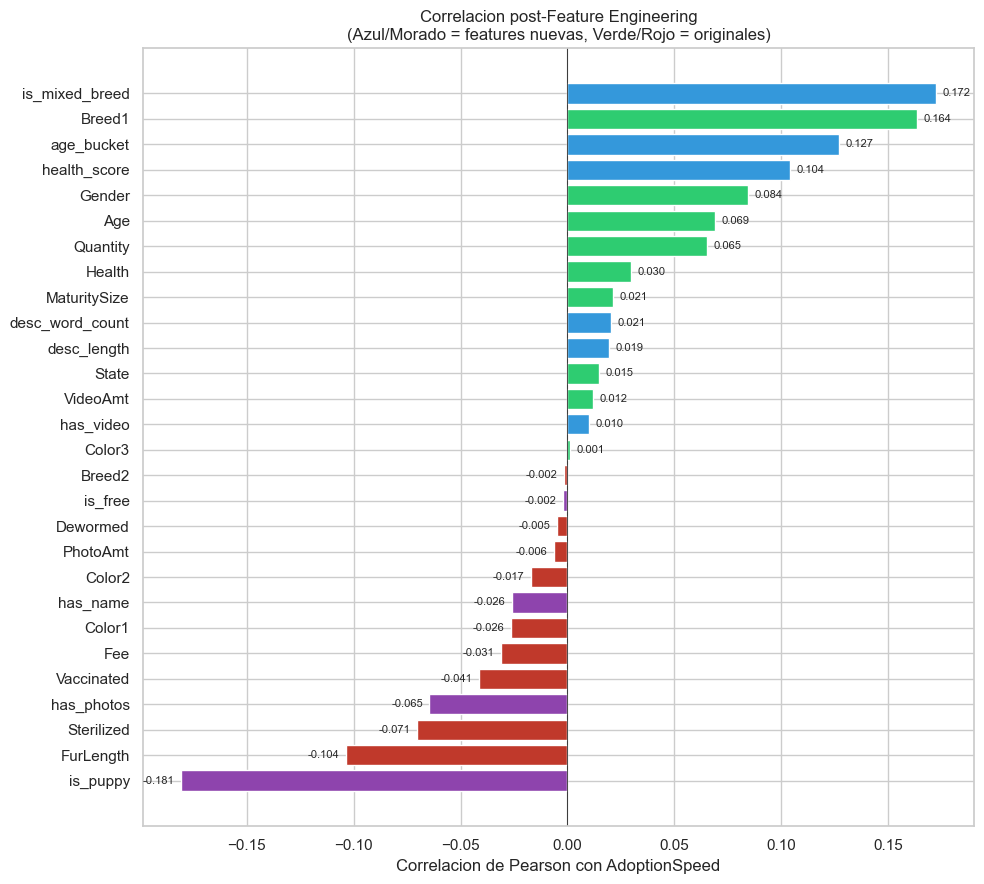

Top 5 features con mayor correlacion (valor absoluto):
  is_puppy             → -0.181 (NUEVA)
  is_mixed_breed       → +0.172 (NUEVA)
  Breed1               → +0.164 (original)
  age_bucket           → +0.127 (NUEVA)
  health_score         → +0.104 (NUEVA)

Features nuevas vs originales:
  Promedio |corr| features nuevas:     0.0728
  Promedio |corr| features originales: 0.0425


In [20]:
# --- Correlaciones POST Feature Engineering ---
numeric_cols_post = dogs.select_dtypes(include=[np.number]).columns.tolist()
for col in ['Type']:
    if col in numeric_cols_post: numeric_cols_post.remove(col)

corrs_post = dogs[numeric_cols_post].corr()['AdoptionSpeed'].drop('AdoptionSpeed').sort_values()

# Separar features originales vs derivadas
new_feats = ['is_mixed_breed', 'has_name', 'is_puppy', 'is_free',
             'desc_length', 'desc_word_count', 'health_score',
             'age_bucket', 'has_photos', 'has_video', 'color_count']

fig, ax = plt.subplots(figsize=(10, 9))
colors_post = []
for feat in corrs_post.index:
    if feat in new_feats:
        colors_post.append('#3498db' if corrs_post[feat] >= 0 else '#8e44ad')  # azul/morado para nuevas
    else:
        colors_post.append('#2ecc71' if corrs_post[feat] >= 0 else '#c0392b')  # verde/rojo para originales

ax.barh(range(len(corrs_post)), corrs_post.values, color=colors_post)
ax.set_yticks(range(len(corrs_post)))
ax.set_yticklabels(corrs_post.index)
ax.set_xlabel('Correlacion de Pearson con AdoptionSpeed')
ax.set_title('Correlacion post-Feature Engineering\n(Azul/Morado = features nuevas, Verde/Rojo = originales)')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, v in enumerate(corrs_post.values):
    ax.text(v + 0.003 if v >= 0 else v - 0.003, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

# Comparar top features
print("Top 5 features con mayor correlacion (valor absoluto):")
top5 = corrs_post.abs().sort_values(ascending=False).head(5)
for feat, val in top5.items():
    tipo = "NUEVA" if feat in new_feats else "original"
    direction = "+" if corrs_post[feat] > 0 else "-"
    print(f"  {feat:20s} → {direction}{val:.3f} ({tipo})")

print(f"\nFeatures nuevas vs originales:")
avg_new = corrs_post[corrs_post.index.isin(new_feats)].abs().mean()
avg_orig = corrs_post[~corrs_post.index.isin(new_feats)].abs().mean()
print(f"  Promedio |corr| features nuevas:     {avg_new:.4f}")
print(f"  Promedio |corr| features originales: {avg_orig:.4f}")

In [21]:
print("Entrenando Random Forest con TODO el train...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model.fit(X, y)
print("Random Forest entrenado")

Entrenando Random Forest con TODO el train...
Random Forest entrenado


### Gradient boosting


In [22]:
print("Entrenando Gradient Boosting con TODO el train...")
print("Esto tarda 3-5 min...\n")

gb_model = GradientBoostingClassifier(
    n_estimators=300, #Numero de arboles a construir.
    max_depth=5, #cuantos nivels profundos
    learning_rate=0.1, #velocidad de aprendizaje
    subsample=0.8, #usar 80% en cada arboles con el fin de evitar overfitting
    random_state=42 #Semilla para reproducibilidad
)
gb_model.fit(X, y)
print("Gradient Boosting entrenado")

Entrenando Gradient Boosting con TODO el train...
Esto tarda 3-5 min...

Gradient Boosting entrenado


### XGBoost


In [23]:
!pip install xgboost 

from xgboost import XGBClassifier

print("Entrenando XGBoost con TODO el train...")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1.0,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X, y)
print("XGBoost entrenado")

zsh:1: command not found: pip
Entrenando XGBoost con TODO el train...
XGBoost entrenado


### Cross validation estratificado


Entrenas con 4 partes y pruebas con 1 parte, esto se repite 5 veces, de esta manera se evalua con todos los datos

In [24]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

##I decided to add f1_micro in case the classes are imbalanced, which is the case here.

print("Cross Validation (5 folds) - Random Forest...")
cv_rf_acc = cross_val_score(rf_model, X, y, cv=cv, scoring='accuracy')
cv_rf_f1_macro  = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_macro')
cv_rf_f1_micro = cross_val_score(rf_model, X, y, cv=cv, scoring='f1_micro')

print(f"  Acc: {[f'{s:.4f}' for s in cv_rf_acc]} | Mean={cv_rf_acc.mean():.4f} (+/- {cv_rf_acc.std():.4f})")
print(f"  F1 (macro):  {[f'{s:.4f}' for s in cv_rf_f1_macro ]} | Mean={cv_rf_f1_macro.mean():.4f} (+/- {cv_rf_f1_macro.std():.4f})")
print(f"  F1 (micro):  {[f'{s:.4f}' for s in cv_rf_f1_micro ]} | Mean={cv_rf_f1_micro.mean():.4f} (+/- {cv_rf_f1_micro.std():.4f})")

print("\nCross Validation (5 folds) - Gradient Boosting...")
##cv is the cross validation strategy, in this case StratifiedKFold con 5 splits, shuffle=True y random_state=42 para reproducibilidad. 
cv_gb_acc = cross_val_score(gb_model, X, y, cv=cv, scoring='accuracy')
cv_gb_f1_macro  = cross_val_score(gb_model, X, y, cv=cv, scoring='f1_macro')
cv_gb_f1_micro = cross_val_score(gb_model, X, y, cv=cv, scoring='f1_micro')
print(f"  Acc: {[f'{s:.4f}' for s in cv_gb_acc]} | Mean={cv_gb_acc.mean():.4f} (+/- {cv_gb_acc.std():.4f})")
print(f"  F1 (macro):  {[f'{s:.4f}' for s in cv_gb_f1_macro ]} | Mean={cv_gb_f1_macro.mean():.4f} (+/- {cv_gb_f1_macro.std():.4f})")
print(f"  F1 (micro):  {[f'{s:.4f}' for s in cv_gb_f1_micro ]} | Mean={cv_gb_f1_micro.mean():.4f} (+/- {cv_gb_f1_micro.std():.4f})")

print("\nCross Validation (5 folds) - XGBoost...")
cv_xgb_acc = cross_val_score(xgb_model, X, y, cv=cv, scoring='accuracy')
cv_xgb_f1_macro = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1_macro')
cv_xgb_f1_micro = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1_micro')
print(f"  Acc: {[f'{s:.4f}' for s in cv_xgb_acc]} | Mean={cv_xgb_acc.mean():.4f} (+/- {cv_xgb_acc.std():.4f})")
print(f"  F1 (macro):  {[f'{s:.4f}' for s in cv_xgb_f1_macro ]} | Mean={cv_xgb_f1_macro.mean():.4f} (+/- {cv_xgb_f1_macro.std():.4f})")
print(f"  F1 (micro):  {[f'{s:.4f}' for s in cv_xgb_f1_micro ]} | Mean={cv_xgb_f1_micro.mean():.4f} (+/- {cv_xgb_f1_micro.std():.4f})")

Cross Validation (5 folds) - Random Forest...
  Acc: ['0.4339', '0.4241', '0.4471', '0.4244', '0.4533'] | Mean=0.4365 (+/- 0.0118)
  F1 (macro):  ['0.4191', '0.4098', '0.4333', '0.4064', '0.4415'] | Mean=0.4220 (+/- 0.0135)
  F1 (micro):  ['0.4339', '0.4241', '0.4471', '0.4244', '0.4533'] | Mean=0.4365 (+/- 0.0118)

Cross Validation (5 folds) - Gradient Boosting...
  Acc: ['0.4327', '0.4462', '0.4446', '0.4379', '0.4416'] | Mean=0.4406 (+/- 0.0049)
  F1 (macro):  ['0.4176', '0.4301', '0.4249', '0.4191', '0.4257'] | Mean=0.4235 (+/- 0.0046)
  F1 (micro):  ['0.4327', '0.4462', '0.4446', '0.4379', '0.4416'] | Mean=0.4406 (+/- 0.0049)

Cross Validation (5 folds) - XGBoost...
  Acc: ['0.4333', '0.4444', '0.4379', '0.4274', '0.4434'] | Mean=0.4373 (+/- 0.0063)
  F1 (macro):  ['0.4186', '0.4297', '0.4207', '0.4057', '0.4268'] | Mean=0.4203 (+/- 0.0083)
  F1 (micro):  ['0.4333', '0.4444', '0.4379', '0.4274', '0.4434'] | Mean=0.4373 (+/- 0.0063)



Modelo                 Acc mean   Acc std    F1 macro mean  F1 micro mean 
------------------------------------------------------------------------
Random Forest          0.4365     0.0118     0.4220         0.4365        
Gradient Boosting      0.4406     0.0049     0.4235         0.4406        
XGBoost                0.4373     0.0063     0.4203         0.4373        
Best by Accuracy:  Gradient Boosting
Best by F1-macro:  Gradient Boosting
Best by F1-micro:  Gradient Boosting
Best model is the best in all metrics: Gradient Boosting

→ Best model: Gradient Boosting (F1-macro: 0.4235, F1-micro: 0.4406, Acc: 0.4406)


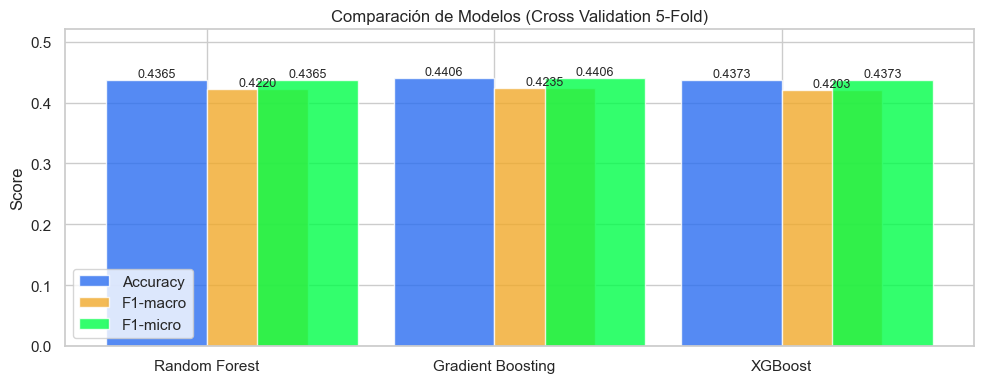

In [25]:
print(f"\n{'='*72}")
print(f"{'Modelo':<22} {'Acc mean':<10} {'Acc std':<10} {'F1 macro mean':<14} {'F1 micro mean':<14}")
print(f"{'-'*72}")
print(f"{'Random Forest':<22} {cv_rf_acc.mean():<10.4f} {cv_rf_acc.std():<10.4f} {cv_rf_f1_macro.mean():<14.4f} {cv_rf_f1_micro.mean():<14.4f}")
print(f"{'Gradient Boosting':<22} {cv_gb_acc.mean():<10.4f} {cv_gb_acc.std():<10.4f} {cv_gb_f1_macro.mean():<14.4f} {cv_gb_f1_micro.mean():<14.4f}")
print(f"{'XGBoost':<22} {cv_xgb_acc.mean():<10.4f} {cv_xgb_acc.std():<10.4f} {cv_xgb_f1_macro.mean():<14.4f} {cv_xgb_f1_micro.mean():<14.4f}")

all_models = {
    "Random Forest":     {"model": rf_model,  "cv_acc": cv_rf_acc,  "cv_f1_macro": cv_rf_f1_macro, "cv_f1_micro": cv_rf_f1_micro},
    "Gradient Boosting": {"model": gb_model,  "cv_acc": cv_gb_acc,  "cv_f1_macro": cv_gb_f1_macro, "cv_f1_micro": cv_gb_f1_micro},
    "XGBoost":           {"model": xgb_model, "cv_acc": cv_xgb_acc, "cv_f1_macro": cv_xgb_f1_macro, "cv_f1_micro": cv_xgb_f1_micro},
}

best_by_acc = max(all_models, key=lambda k: all_models[k]["cv_acc"].mean())
best_by_f1_macro = max(all_models, key=lambda k: all_models[k]["cv_f1_macro"].mean())
best_by_f1_micro = max(all_models, key=lambda k: all_models[k]["cv_f1_micro"].mean())

print(f"Best by Accuracy:  {best_by_acc}")
print(f"Best by F1-macro:  {best_by_f1_macro}")
print(f"Best by F1-micro:  {best_by_f1_micro}")

##In this case, all three metrics agree with the same best model, use it
##otherwise a tie exists use the best model by F1-macro as the tiebreaker, since it is more robust to class imbalance and gives a better sense of overall performance across all classes.

if best_by_acc == best_by_f1_macro == best_by_f1_micro:
    print(f"Best model is the best in all metrics: {best_by_acc}")
    best_name = best_by_acc
else:
    printf(f"Tie exists between metrics, using F1-macro as tiebreaker: {best_by_f1_macro}")
    best_name = best_by_f1_macro

best_model = all_models[best_name]["model"] 
best_cv_acc = all_models[best_name]["cv_acc"]
best_cv_f1_macro = all_models[best_name]["cv_f1_macro"]
best_cv_f1_micro = all_models[best_name]["cv_f1_micro"]

print(f"\n→ Best model: {best_name} (F1-macro: {best_cv_f1_macro.mean():.4f}, F1-micro: {best_cv_f1_micro.mean():.4f}, Acc: {best_cv_acc.mean():.4f})")

# Visualización
fig, ax = plt.subplots(figsize=(10, 4))
model_names = list(all_models.keys())
acc_means = [all_models[m]["cv_acc"].mean() for m in model_names]
f1_macro_means = [all_models[m]["cv_f1_macro"].mean() for m in model_names]
f1_micro_means = [all_models[m]["cv_f1_micro"].mean() for m in model_names]
x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, acc_means, width, label='Accuracy', color='#2a6df0', alpha=0.8)
ax.bar(x + width/2, f1_macro_means, width, label='F1-macro', color='#f0a92a', alpha=0.8)
ax.bar(x + width, f1_micro_means, width, label='F1-micro', color="#00fe48", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel('Score')
ax.set_title('Comparación de Modelos (Cross Validation 5-Fold)')
ax.legend()
for i in range(len(model_names)):
    ax.text(i - width/2, acc_means[i] + 0.005, f'{acc_means[i]:.4f}', ha='center', fontsize=9)
    ax.text(i + width/2, f1_macro_means[i] + 0.005, f'{f1_macro_means[i]:.4f}', ha='center', fontsize=9)
    ax.text(i + width, f1_micro_means[i] + 0.005, f'{f1_micro_means[i]:.4f}', ha='center', fontsize=9)
ax.set_ylim(0, max(max(acc_means), max(f1_macro_means), max(f1_micro_means)) + 0.08)
plt.tight_layout()
plt.show()

In [28]:
# Split temporal solo para métricas detalladas
##vamos a entrenarlo ahora 80/20, 20% de validacion
X_temp_tr, X_temp_val, y_temp_tr, y_temp_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)##shuffle the data before splitting, maintaining class distribution.

# print("1",X_temp_tr)
# print("2",y_temp_tr)

temp_model = best_model.__class__(**best_model.get_params())
print("tempo model -->", temp_model)
temp_model.fit(X_temp_tr, y_temp_tr) ##train the model with the split
##data & labels

y_val_pred = temp_model.predict(X_temp_val)
y_val_proba = temp_model.predict_proba(X_temp_val)

# Métricas
acc = accuracy_score(y_temp_val, y_val_pred)

print(f"MÉTRICAS DETALLADAS — {best_name}")
print(f"\n  Accuracy:           {acc:.4f}   (% predicciones correctas)")
print(f"  F1-macro (CV):      {best_cv_f1_macro.mean():.4f}   (promedio F1 por clase, tratadas por igual)")

print(f"\nClassification Report:")
print(classification_report(y_temp_val, y_val_pred,
    target_names=['0-Menos de 1 semana', '1-Mes', '2-Trimestre', '3-No adoptado']))

print("Nota: métricas calculadas sobre split temporal 80/20.")
print("El modelo final fue entrenado con el 100% de los datos.")

tempo model --> GradientBoostingClassifier(max_depth=5, n_estimators=300, random_state=42,
                           subsample=0.8)
MÉTRICAS DETALLADAS — Gradient Boosting

  Accuracy:           0.4462   (% predicciones correctas)
  F1-macro (CV):      0.4235   (promedio F1 por clase, tratadas por igual)

Classification Report:
                     precision    recall  f1-score   support

0-Menos de 1 semana       0.43      0.38      0.41       321
              1-Mes       0.35      0.36      0.36       433
        2-Trimestre       0.43      0.39      0.41       390
      3-No adoptado       0.55      0.60      0.58       483

           accuracy                           0.45      1627
          macro avg       0.44      0.44      0.44      1627
       weighted avg       0.44      0.45      0.44      1627

Nota: métricas calculadas sobre split temporal 80/20.
El modelo final fue entrenado con el 100% de los datos.


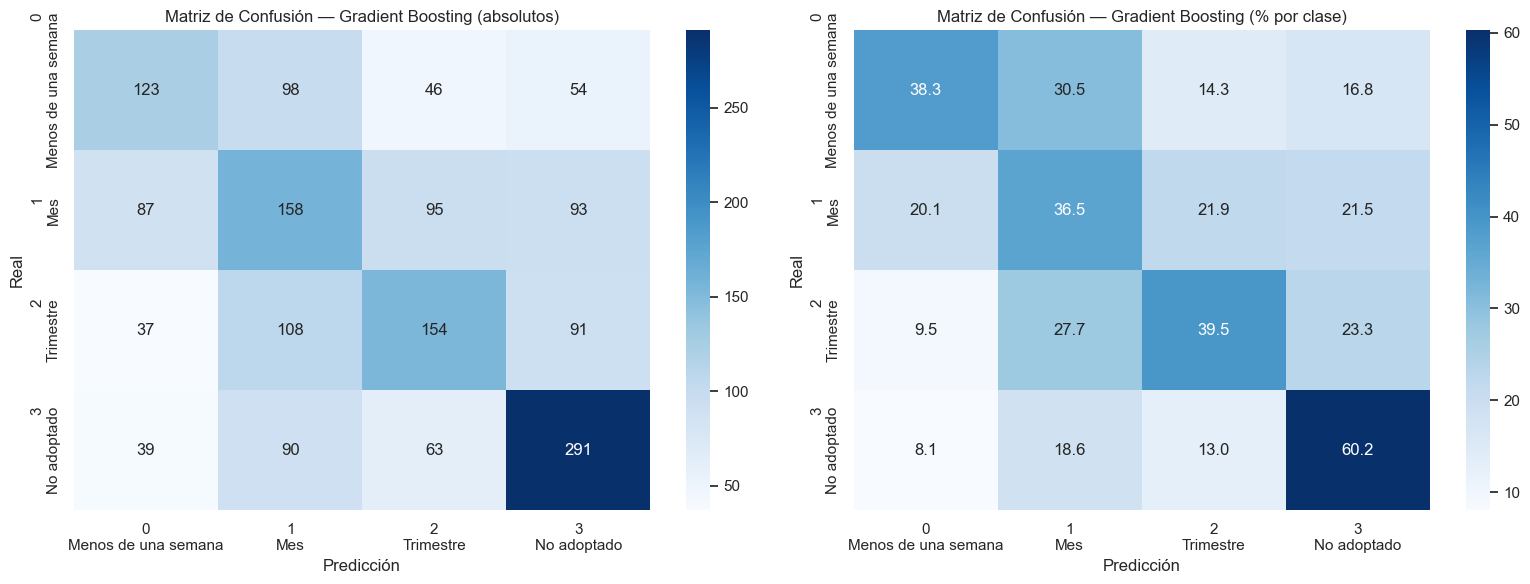

Análisis de errores:
  - Clase 0 (mismo día) tiene muy pocas muestras → difícil de predecir
  - El modelo confunde más entre clases adyacentes (1↔2, 3↔4)
  - Normal: la diferencia entre 'semana' y 'mes' es sutil


In [29]:
cm = confusion_matrix(y_temp_val, y_val_pred)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_labels = ['0\nMenos de una semana', '1\nMes', '2\nTrimestre', '3\nNo adoptado']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=cm_labels, yticklabels=cm_labels)
axes[0].set_title(f'Matriz de Confusión — {best_name} (absolutos)')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=cm_labels, yticklabels=cm_labels)
axes[1].set_title(f'Matriz de Confusión — {best_name} (% por clase)')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

print("Análisis de errores:")
print("  - Clase 0 (mismo día) tiene muy pocas muestras → difícil de predecir")
print("  - El modelo confunde más entre clases adyacentes (1↔2, 3↔4)")
print("  - Normal: la diferencia entre 'semana' y 'mes' es sutil")

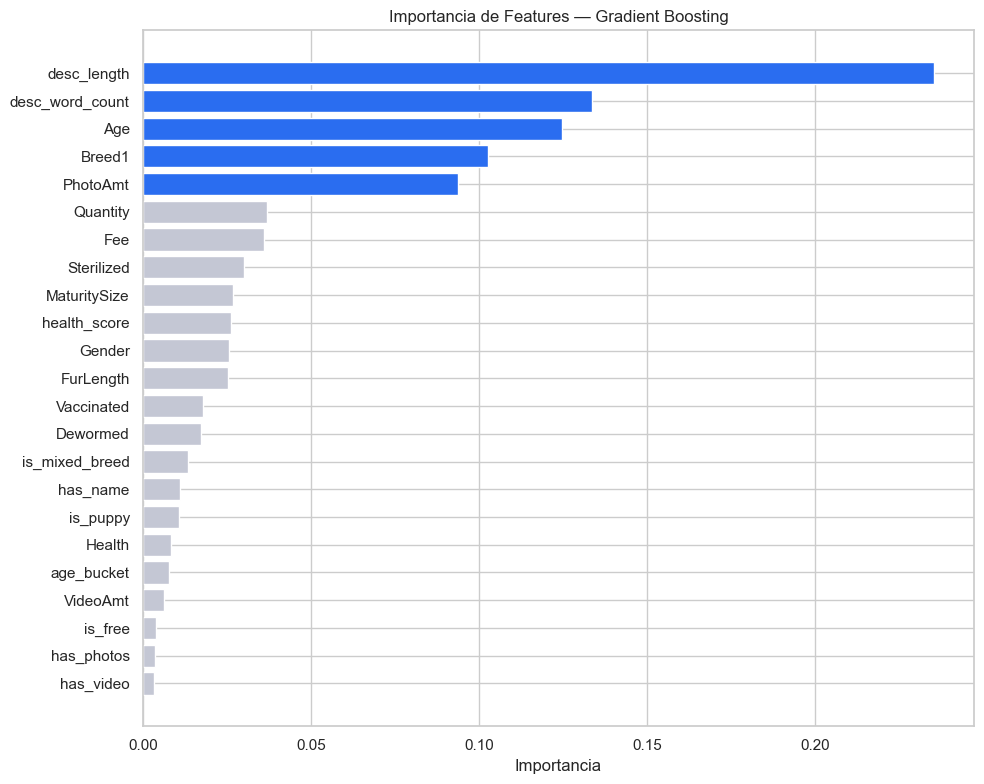

Top 10 features:
   1. desc_length          0.2355 ███████████████████████████████████
   2. desc_word_count      0.1336 ████████████████████
   3. Age                  0.1246 ██████████████████
   4. Breed1               0.1027 ███████████████
   5. PhotoAmt             0.0936 ██████████████
   6. Quantity             0.0368 █████
   7. Fee                  0.0362 █████
   8. Sterilized           0.0301 ████
   9. MaturitySize         0.0267 ███
  10. health_score         0.0262 ███
  11. Gender               0.0255 ███
  12. FurLength            0.0253 ███
  13. Vaccinated           0.0178 ██
  14. Dewormed             0.0173 ██
  15. is_mixed_breed       0.0133 ██
  16. has_name             0.0111 █
  17. is_puppy             0.0108 █
  18. Health               0.0083 █
  19. age_bucket           0.0078 █
  20. VideoAmt             0.0063 
  21. is_free              0.0039 
  22. has_photos           0.0035 
  23. has_video            0.0033 


In [30]:
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors_fi = ['#2a6df0' if imp > 0.05 else '#c4c7d4' for imp in feat_imp['importance']]
ax.barh(range(len(feat_imp)), feat_imp['importance'], color=colors_fi)
ax.set_yticks(range(len(feat_imp)))
ax.set_yticklabels(feat_imp['feature'])
ax.set_xlabel('Importancia')
ax.set_title(f'Importancia de Features — {best_name}')
plt.tight_layout()
plt.show()

print("Top 10 features:")
for i, (_, row) in enumerate(feat_imp.sort_values('importance', ascending=False).head(24).iterrows()):
    bar = "█" * int(row['importance'] * 150)
    print(f"  {i+1:2d}. {row['feature']:20s} {row['importance']:.4f} {bar}")

Comparando accuracy con diferentes números de features...

  Top  5 features → Accuracy: 0.3987
  Top 10 features → Accuracy: 0.4220
  Top 15 features → Accuracy: 0.4358
  Top 20 features → Accuracy: 0.4362
  Top 25 features → Accuracy: 0.4351


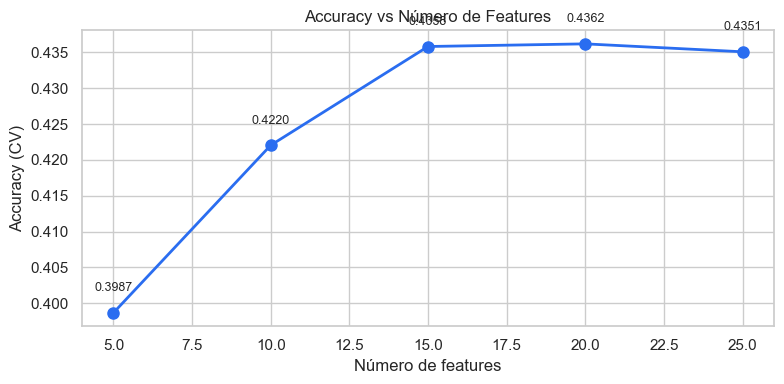


→ Si la accuracy no mejora mucho después de 15 features,
  las últimas 10 features aportan poco (pero tampoco perjudican)


In [31]:
print("Comparando accuracy con diferentes números de features...\n")

top_features = feat_imp.sort_values('importance', ascending=False)['feature'].tolist()

results_feat_sel = {}
for n in [5, 10, 15, 20, 25]:
    feats = top_features[:n]
    scores = cross_val_score(
        best_model.__class__(**best_model.get_params()),
        X[feats], y, cv=cv, scoring='accuracy'
    )
    results_feat_sel[n] = scores.mean()
    print(f"  Top {n:2d} features → Accuracy: {scores.mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ns = list(results_feat_sel.keys())
accs = list(results_feat_sel.values())
ax.plot(ns, accs, 'o-', color='#2a6df0', linewidth=2, markersize=8)
ax.set_xlabel('Número de features')
ax.set_ylabel('Accuracy (CV)')
ax.set_title('Accuracy vs Número de Features')
for n, a in zip(ns, accs):
    ax.text(n, a + 0.003, f'{a:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\n→ Si la accuracy no mejora mucho después de 15 features,")
print("  las últimas 10 features aportan poco (pero tampoco perjudican)")


In [32]:
print(f"{'='*60}")
print("CUESTIONARIO DE 20 PREGUNTAS (4 categorías × 5)")
print(f"{'='*60}")

print("""
📋 CATEGORÍA 1: ESTILO DE VIDA Y ACTIVIDAD
   Se compara con: Age + MaturitySize del perro
   ─────────────────────────────────────────────
   Q1:  ¿Qué tan activo eres físicamente durante la semana?
        1=Sedentario ... 5=Muy activo
   Q2:  ¿Con qué frecuencia podrías sacar a pasear a un perro?
        1=Rara vez ... 5=Varias veces al día
   Q3:  ¿Qué tan importante es para ti hacer actividades al aire libre?
        1=Nada ... 5=Muy importante
   Q4:  ¿Cuánto tiempo podrías dedicar diariamente al ejercicio con tu perro?
        1=Menos de 15min ... 5=Más de 2 horas
   Q5:  ¿Qué tan cómodo te sientes con un perro muy enérgico?
        1=Nada cómodo ... 5=Muy cómodo

📋 CATEGORÍA 2: HOGAR Y ESPACIO
   Se compara con: MaturitySize del perro
   ─────────────────────────────────────────────
   Q6:  ¿Qué tipo de vivienda tienes?
        1=Depto pequeño ... 5=Casa con jardín grande
   Q7:  ¿Tienes acceso a un espacio exterior donde el perro pueda moverse?
        1=Sin acceso ... 5=Jardín/parque propio
   Q8:  ¿Qué tan cómodo estás con perros grandes dentro del hogar?
        1=Nada cómodo ... 5=Muy cómodo
   Q9:  ¿Qué tan tranquilo o ruidoso es tu hogar normalmente?
        1=Muy ruidoso ... 5=Muy tranquilo
   Q10: ¿Cuántas personas viven en tu casa?
        1=Vivo solo ... 5=Familia grande (5+)

CATEGORÍA 3: EXPERIENCIA Y ENTRENAMIENTO
   Se compara con: Age (cachorros necesitan entrenamiento) + Health
   ─────────────────────────────────────────────
   Q11: ¿Has tenido perros antes?
        1=Nunca ... 5=Muchos años de experiencia
   Q12: ¿Qué tan cómodo te sientes entrenando a un perro?
        1=Nada cómodo ... 5=Muy experimentado
   Q13: ¿Cuánta paciencia tienes para enseñar comportamientos nuevos?
        1=Poca ... 5=Mucha
   Q14: ¿Estarías dispuesto a asistir a clases de entrenamiento?
        1=No ... 5=Definitivamente
   Q15: ¿Qué tan preparado te sientes para adaptarte a un perro rescatado?
        1=Nada preparado ... 5=Totalmente preparado

CATEGORÍA 4: RECURSOS Y CUIDADOS
   Se compara con: Health + health_score + Fee del perro
   ─────────────────────────────────────────────
   Q16: ¿Qué tan preparado estás para cubrir gastos veterinarios inesperados?
        1=Nada preparado ... 5=Totalmente preparado
   Q17: ¿Qué tan cómodo estás administrando medicación si fuera necesario?
        1=Nada cómodo ... 5=Muy cómodo
   Q18: ¿Cuánto podrías gastar mensualmente en el cuidado de tu perro?
        1=Muy poco ... 5=Sin restricción
   Q19: ¿Estarías dispuesto a pagar tratamientos médicos si el perro lo necesitara?
        1=No ... 5=Sin duda
   Q20: ¿Qué tan comprometido estás con mantener vacunas y cuidados preventivos?
        1=Poco ... 5=Totalmente comprometido
""")

CUESTIONARIO DE 20 PREGUNTAS (4 categorías × 5)

📋 CATEGORÍA 1: ESTILO DE VIDA Y ACTIVIDAD
   Se compara con: Age + MaturitySize del perro
   ─────────────────────────────────────────────
   Q1:  ¿Qué tan activo eres físicamente durante la semana?
        1=Sedentario ... 5=Muy activo
   Q2:  ¿Con qué frecuencia podrías sacar a pasear a un perro?
        1=Rara vez ... 5=Varias veces al día
   Q3:  ¿Qué tan importante es para ti hacer actividades al aire libre?
        1=Nada ... 5=Muy importante
   Q4:  ¿Cuánto tiempo podrías dedicar diariamente al ejercicio con tu perro?
        1=Menos de 15min ... 5=Más de 2 horas
   Q5:  ¿Qué tan cómodo te sientes con un perro muy enérgico?
        1=Nada cómodo ... 5=Muy cómodo

📋 CATEGORÍA 2: HOGAR Y ESPACIO
   Se compara con: MaturitySize del perro
   ─────────────────────────────────────────────
   Q6:  ¿Qué tipo de vivienda tienes?
        1=Depto pequeño ... 5=Casa con jardín grande
   Q7:  ¿Tienes acceso a un espacio exterior donde el perro

Aqui se hace la conversion del vector de usuario, y tambien la conversion de perro a vector, son vectores de 4 dimensiones para ver la compatibilidad.


In [34]:
def compute_user_vector(answers):
    """
    Recibe las 20 respuestas (escala 1-5) y calcula el vector de 4 dimensiones.

    answers: dict con keys 'q1' a 'q20', valores de 1 a 5

    Retorna: [activity_score, housing_score, experience_score, care_score]
    """
    activity_score   = np.mean([answers[f'q{i}'] for i in range(1, 6)])
    housing_score    = np.mean([answers[f'q{i}'] for i in range(6, 11)])
    experience_score = np.mean([answers[f'q{i}'] for i in range(11, 16)])
    care_score       = np.mean([answers[f'q{i}'] for i in range(16, 21)])

    return [activity_score, housing_score, experience_score, care_score]


def compute_dog_vector(dog):
    """
    Convierte las features de un perro en el mismo espacio de 4 dimensiones.

    dog: dict con keys del perfil del perro

    Retorna: [activity_req, space_req, training_diff, care_req]
    """
    age = dog['Age']

    # Actividad requerida (1-5):
    # Cachorros y perros jóvenes = más energía
    # Perros grandes = más ejercicio necesario
    age_activity = 5.0 if age <= 6 else (4.0 if age <= 24 else (3.0 if age <= 84 else 2.0))
    size_activity = {1: 2.0, 2: 3.0, 3: 4.0, 4: 5.0}.get(dog['MaturitySize'], 3.0)
    activity_req = (age_activity + size_activity) / 2

    # Espacio requerido (1-5):
    # Directamente del tamaño
    space_req = {1: 1.5, 2: 2.5, 3: 3.5, 4: 5.0}.get(dog['MaturitySize'], 3.0)

    # Dificultad de entrenamiento (1-5):
    # Cachorros necesitan más entrenamiento
    # Perros con problemas de salud requieren más experiencia
    age_train = 5.0 if age <= 6 else (4.0 if age <= 12 else (3.0 if age <= 48 else 2.0))
    health_train = {1: 1.0, 2: 3.0, 3: 5.0}.get(dog['Health'], 2.0)
    training_diff = (age_train + health_train) / 2

    # Necesidad de cuidados (1-5):
    # Basado en salud y tratamientos médicos previos
    health_base = {1: 1.0, 2: 3.0, 3: 5.0}.get(dog['Health'], 2.0)
    # health_score: 0 = sin tratamientos, 3 = todos los tratamientos
    # Un perro SIN tratamientos NECESITA más cuidados del adoptante
    medical_need = 5.0 - dog.get('health_score', 0) * (4.0/3.0)  # 0→5.0, 3→1.0
    care_req = (health_base + medical_need) / 2

    return [activity_req, space_req, training_diff, care_req]


def compute_similarity(user_vector, dog_vector):
    """
    Calcula la similitud entre el vector del usuario y el del perro
    usando distancia euclidiana normalizada.

    Ambos vectores tienen 4 dimensiones con rango [1, 5].
    Distancia máxima posible = sqrt(4 * (5-1)^2) = sqrt(64) = 8

    Retorna: float entre 0.0 (incompatible) y 1.0 (match perfecto)
    """
    user_arr = np.array(user_vector)
    dog_arr = np.array(dog_vector)

    distance = np.sqrt(np.sum((user_arr - dog_arr) ** 2))
    max_distance = np.sqrt(4 * (5 - 1) ** 2)  # = 8.0

    similarity = 1.0 - (distance / max_distance)
    return round(max(0.0, similarity), 4)


def dog_to_ml_features(dog):
    """
    Convierte el perfil de un perro al DataFrame de 25 features
    que el modelo necesita para predict_proba.
    """
    desc = dog.get("Description", "")
    return pd.DataFrame([{
        'Age': dog['Age'],
        'Breed1': dog['Breed1'],
        'Gender': dog['Gender'],
        'Color1': dog['Color1'],
        'MaturitySize': dog['MaturitySize'],
        'FurLength': dog['FurLength'],
        'Vaccinated': dog['Vaccinated'],
        'Dewormed': dog['Dewormed'],
        'Sterilized': dog['Sterilized'],
        'Health': dog['Health'],
        'Quantity': dog['Quantity'],
        'Fee': dog['Fee'],
        'PhotoAmt': dog['PhotoAmt'],
        'VideoAmt': dog['VideoAmt'],
        'is_mixed_breed': 1 if dog.get('Breed2', 0) != 0 else 0,
        'has_name': 1 if dog.get('Name') else 0,
        'is_puppy': 1 if dog['Age'] <= 3 else 0,
        'is_free': 1 if dog['Fee'] == 0 else 0,
        'desc_length': len(desc),
        'desc_word_count': len(desc.split()) if desc else 0,
        'health_score': (
            (1 if dog['Vaccinated'] == 1 else 0) +
            (1 if dog['Dewormed'] == 1 else 0) +
            (1 if dog['Sterilized'] == 1 else 0)
        ),
        'age_bucket': (
            0 if dog['Age'] <= 3 else
            1 if dog['Age'] <= 12 else
            2 if dog['Age'] <= 48 else 3
        ),
        'has_photos': 1 if dog['PhotoAmt'] > 0 else 0,
        'has_video': 1 if dog['VideoAmt'] > 0 else 0,
    }])
def compute_ml_score(dog, model, feature_cols):
    """
    Calcula la probabilidad de adopción exitosa (≤30 días).
    Suma P(speed 0) + P(speed 1) + P(speed 2).
    """
    features_df = dog_to_ml_features(dog)
    probs = model.predict_proba(features_df[feature_cols])[0]
    ml_score = sum(probs[:3])  # P(adopted within 30 days)
    return round(ml_score, 4), probs


def compute_compatibility(similarity, ml_score, alpha=0.6, beta=0.4):
    """
    Score final de compatibilidad.
    alpha: peso de la similitud (preferencias del adoptante)
    beta: peso del ML (probabilidad real de adopción)
    alpha + beta = 1
    """
    return round(alpha * similarity + beta * ml_score, 4)

print("Funciones del pipeline definidas")
print("  - compute_user_vector: 20 respuestas → vector [4d]")
print("  - compute_dog_vector: perfil del perro → vector [4d]")
print("  - compute_similarity: distancia euclidiana → similitud 0-1")
print("  - compute_ml_score: 25 features → probabilidad adopción")
print("  - compute_compatibility: α×similitud + β×ml_score")

Funciones del pipeline definidas
  - compute_user_vector: 20 respuestas → vector [4d]
  - compute_dog_vector: perfil del perro → vector [4d]
  - compute_similarity: distancia euclidiana → similitud 0-1
  - compute_ml_score: 25 features → probabilidad adopción
  - compute_compatibility: α×similitud + β×ml_score


### Celda 20: Definir el cuestionario


In [35]:
print(f"\n{'='*60}")
print("SIMULACIÓN del pipeline con un adoptante y 4 perros de ejemplo")
print(f"{'='*60}")

#  Adoptante responde 20 preguntas
print("\n Respuestas del adoptante (escala 1-5)")
adopter_answers = {
    # Categoría 1: Estilo de vida
    'q1': 4,   # Muy activo
    'q2': 4,   # Paseos frecuentes
    'q3': 5,   # Le importa el aire libre
    'q4': 3,   # 30min-1h de ejercicio
    'q5': 4,   # Cómodo con perro enérgico
    # Categoría 2: Hogar
    'q6': 3,   # Depto grande
    'q7': 3,   # Algo de espacio exterior
    'q8': 3,   # Neutral con perros grandes
    'q9': 3,   # Hogar moderadamente tranquilo
    'q10': 2,  # 2 personas
    # Categoría 3: Experiencia
    'q11': 3,  # Algo de experiencia
    'q12': 2,  # Poco cómodo entrenando
    'q13': 4,  # Bastante paciencia
    'q14': 4,  # Dispuesto a clases
    'q15': 3,  # Moderadamente preparado
    # Categoría 4: Recursos
    'q16': 4,  # Preparado para gastos
    'q17': 3,  # Neutral con medicación
    'q18': 3,  # Gasto medio mensual
    'q19': 4,  # Dispuesto a tratamientos
    'q20': 5,  # Totalmente comprometido con vacunas
}

user_vector = compute_user_vector(adopter_answers)
labels_cats = ['Actividad', 'Hogar', 'Experiencia', 'Recursos']
print(f"   Vector usuario: {[f'{v:.1f}' for v in user_vector]}")
for label, score in zip(labels_cats, user_vector):
    bar = "█" * int(score * 10)
    print(f"     {label:15s}: {score:.1f}/5.0 {bar}")

# Perros disponibles
print(f"\nPerros en la base de datos, mock data")
available_dogs = [
    {"Name": "Max",    "Age": 3,  "Breed1": 307, "Breed2": 0,   "Gender": 1, "Color1": 2, "Color2": 7, "Color3": 0,
     "MaturitySize": 2, "FurLength": 1, "Vaccinated": 1, "Dewormed": 1, "Sterilized": 1,
     "Health": 1, "Quantity": 1, "Fee": 0, "PhotoAmt": 5, "VideoAmt": 0,
     "Description": "Max es un cachorro juguetón y cariñoso. Le encanta correr y jugar con pelotas. Ideal para familias activas con espacio al aire libre. Está vacunado y desparasitado."},
    {"Name": "Rocky",  "Age": 3,  "Breed1": 307, "Breed2": 0,   "Gender": 1, "Color1": 1, "Color2": 0, "Color3": 0,
     "MaturitySize": 2, "FurLength": 1, "Vaccinated": 1, "Dewormed": 1, "Sterilized": 1,
     "Health": 1, "Quantity": 1, "Fee": 0, "PhotoAmt": 0, "VideoAmt": 0,
     "Description": "Perro."},
    {"Name": "Luna",   "Age": 84, "Breed1": 266, "Breed2": 0,   "Gender": 2, "Color1": 5, "Color2": 0, "Color3": 0,
     "MaturitySize": 4, "FurLength": 3, "Vaccinated": 2, "Dewormed": 2, "Sterilized": 2,
     "Health": 1, "Quantity": 1, "Fee": 1000, "PhotoAmt": 2, "VideoAmt": 0,
     "Description": "Luna es una perra mayor pero muy cariñosa y tranquila. Busca un hogar donde descansar."},
    {"Name": "Canela", "Age": 6,  "Breed1": 252, "Breed2": 179, "Gender": 2, "Color1": 3, "Color2": 5, "Color3": 0,
     "MaturitySize": 1, "FurLength": 2, "Vaccinated": 1, "Dewormed": 1, "Sterilized": 2,
     "Health": 1, "Quantity": 1, "Fee": 200, "PhotoAmt": 3, "VideoAmt": 0,
     "Description": "Canela es una mestiza pequeña y dulce. Se lleva bien con otros perros y gatos. Perfecta para departamentos."},
    {"Name": "Thor",   "Age": 24, "Breed1": 141, "Breed2": 0,   "Gender": 1, "Color1": 3, "Color2": 7, "Color3": 0,
     "MaturitySize": 3, "FurLength": 2, "Vaccinated": 1, "Dewormed": 1, "Sterilized": 1,
     "Health": 2, "Quantity": 1, "Fee": 300, "PhotoAmt": 4, "VideoAmt": 1,
     "Description": "Thor es un Golden Retriever joven con una lesión menor en la pata. Es muy juguetón y leal. Necesita un hogar con espacio y un dueño con algo de experiencia."},
]

for d in available_dogs:
    print(f"   {d['Name']:10s} | Age:{d['Age']:3d}mo | Size:{d['MaturitySize']} | Health:{d['Health']} | Photos:{d['PhotoAmt']} | Fee:${d['Fee']}")

# Calcular vectores de perros
print(f"\nConvertir perros a vectores de 4 dimensiones")
dog_vectors = {}
for dog in available_dogs:
    dv = compute_dog_vector(dog)
    dog_vectors[dog['Name']] = dv
    print(f"   {dog['Name']:10s} → [{', '.join(f'{v:.1f}' for v in dv)}]")
    print(f"              (actividad={dv[0]:.1f}, espacio={dv[1]:.1f}, entrenamiento={dv[2]:.1f}, cuidados={dv[3]:.1f})")

# Distancia euclidiana
print(f"\nDistancia euclidiana → Similitud")
similarities = {}
for dog in available_dogs:
    sim = compute_similarity(user_vector, dog_vectors[dog['Name']])
    similarities[dog['Name']] = sim
    dist = np.sqrt(np.sum((np.array(user_vector) - np.array(dog_vectors[dog['Name']])) ** 2))
    print(f"   {dog['Name']:10s} → distancia={dist:.2f}, similitud={sim:.4f}")

# ML predict_proba
print(f"\nML predict_proba (25 features del perro)")
ml_scores = {}
all_probs = {}
for dog in available_dogs:
    ml, probs = compute_ml_score(dog, best_model, FEATURE_COLS)
    ml_scores[dog['Name']] = ml
    all_probs[dog['Name']] = probs
    print(f"   {dog['Name']:10s} → probs=[{', '.join(f'{p:.2f}' for p in probs)}] → ml_score={ml:.4f}")

# Compatibilidad final
print(f"\ncompatibilidad = 0.6 × similitud + 0.4 × ml_score")
alpha = 0.6
beta = 0.4

results = []
for dog in available_dogs:
    n = dog['Name']
    sim = similarities[n]
    ml = ml_scores[n]
    compat = compute_compatibility(sim, ml, alpha, beta)
    results.append({
        "name": n, "similarity": sim, "ml_score": ml,
        "compatibility": compat, "probs": all_probs[n]
    })

results.sort(key=lambda x: x["compatibility"], reverse=True)

print(f"\nRecomendaciones finales:")
for i, r in enumerate(results):
    medal = ["1", "2", "3"][i] if i < 3 else f"  {i+1}."
    print(f"   {medal} {r['name']:10s} | sim={r['similarity']:.2f} | ml={r['ml_score']:.2f} | compatibilidad={r['compatibility']:.0%}")


SIMULACIÓN del pipeline con un adoptante y 4 perros de ejemplo

 Respuestas del adoptante (escala 1-5)
   Vector usuario: ['4.0', '2.8', '3.2', '3.8']
     Actividad      : 4.0/5.0 ████████████████████████████████████████
     Hogar          : 2.8/5.0 ████████████████████████████
     Experiencia    : 3.2/5.0 ████████████████████████████████
     Recursos       : 3.8/5.0 ██████████████████████████████████████

Perros en la base de datos, mock data
   Max        | Age:  3mo | Size:2 | Health:1 | Photos:5 | Fee:$0
   Rocky      | Age:  3mo | Size:2 | Health:1 | Photos:0 | Fee:$0
   Luna       | Age: 84mo | Size:4 | Health:1 | Photos:2 | Fee:$1000
   Canela     | Age:  6mo | Size:1 | Health:1 | Photos:3 | Fee:$200
   Thor       | Age: 24mo | Size:3 | Health:2 | Photos:4 | Fee:$300

Convertir perros a vectores de 4 dimensiones
   Max        → [4.0, 2.5, 3.0, 3.0]
              (actividad=4.0, espacio=2.5, entrenamiento=3.0, cuidados=3.0)
   Rocky      → [4.0, 2.5, 3.0, 3.0]
              

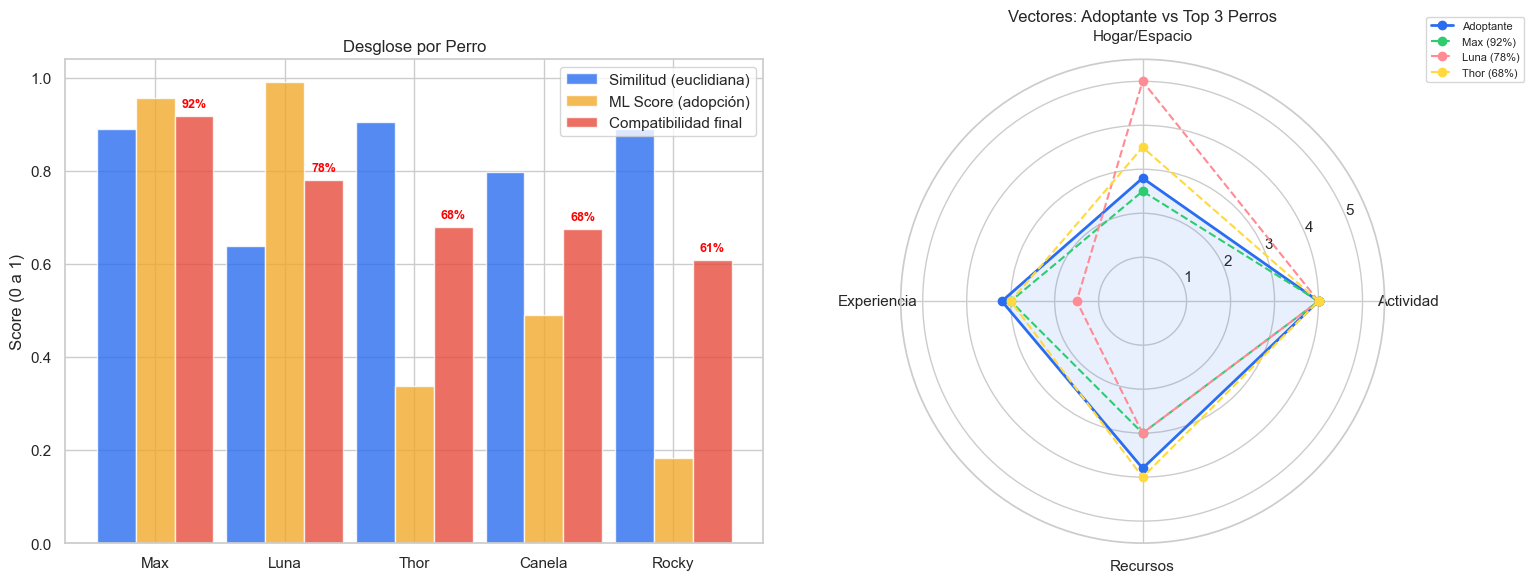

Azul = similitud (¿el perro coincide con el estilo de vida del adoptante?)
Naranja = ML score (¿el perro será adoptado exitosamente?)
Rojo = compatibilidad final (combinación ponderada)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de barras
names = [r["name"] for r in results]
sims = [r["similarity"] for r in results]
mls = [r["ml_score"] for r in results]
compats = [r["compatibility"] for r in results]
x = np.arange(len(names))
width = 0.3

axes[0].bar(x - width, sims, width, label='Similitud (euclidiana)', color='#2a6df0', alpha=0.8)
axes[0].bar(x, mls, width, label='ML Score (adopción)', color='#f0a92a', alpha=0.8)
axes[0].bar(x + width, compats, width, label='Compatibilidad final', color='#e74c3c', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylabel('Score (0 a 1)')
axes[0].set_title('Desglose por Perro')
axes[0].legend()
for i, v in enumerate(compats):
    axes[0].text(i + width, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold', color='red', fontsize=9)

# Radar chart de vectores
from matplotlib.patches import FancyBboxPatch
angles = np.linspace(0, 2 * np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

ax_radar = axes[1]
ax_radar.remove()
ax_radar = fig.add_subplot(122, polar=True)

user_vals = user_vector + [user_vector[0]]
ax_radar.plot(angles, user_vals, 'o-', linewidth=2, label='Adoptante', color='#2a6df0')
ax_radar.fill(angles, user_vals, alpha=0.1, color='#2a6df0')

colors_dogs = ['#2ecc71', '#ff8b94', '#ffd93d', '#a8e6cf', '#c0392b']
for i, r in enumerate(results[:3]):  # Top 3
    dog = [d for d in available_dogs if d['Name'] == r['name']][0]
    dv = dog_vectors[r['name']]
    vals = dv + [dv[0]]
    ax_radar.plot(angles, vals, 'o-', linewidth=1.5, label=f"{r['name']} ({r['compatibility']:.0%})",
                  color=colors_dogs[i], linestyle='--')

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(['Actividad', 'Hogar/Espacio', 'Experiencia', 'Recursos'])
ax_radar.set_ylim(0, 5.5)
ax_radar.set_title('Vectores: Adoptante vs Top 3 Perros')
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

print("Azul = similitud (¿el perro coincide con el estilo de vida del adoptante?)")
print("Naranja = ML score (¿el perro será adoptado exitosamente?)")
print("Rojo = compatibilidad final (combinación ponderada)")

Exportando el modelo

In [ ]:

print("EXPORTANDO MODELO")

joblib.dump(best_model, 'adoption_model.pkl')
print("se guardo")

config = {
    "model_type": best_name,
    "task": "multi-class classification (AdoptionSpeed 0-4)",
    "classes": {str(k): v for k, v in speed_labels.items()},
    "feature_columns": FEATURE_COLS,
    "n_features": len(FEATURE_COLS),
    "metrics": {
        "cv_accuracy_mean": float(best_cv_acc.mean()),
        "cv_accuracy_std": float(best_cv_acc.std()),
        "cv_f1_macro_mean": float(best_cv_f1_macro.mean()),
        "cv_f1_macro_std": float(best_cv_f1_macro.std())
    },
    "compatibility": {
        "formula": "alpha * similarity + beta * ml_score",
        "alpha": alpha,
        "beta": beta,
        "similarity_method": "Euclidean distance normalized to [0,1]",
        "ml_score_method": "sum of predict_proba for classes 0,1,2 (adopted within 30 days)"
    },
    "questionnaire": {
        "total_questions": 20,
        "categories": {
            "activity": {
                "questions": "Q1-Q5",
                "compares_with": "Age + MaturitySize"
            },
            "housing": {
                "questions": "Q6-Q10",
                "compares_with": "MaturitySize"
            },
            "experience": {
                "questions": "Q11-Q15",
                "compares_with": "Age + Health"
            },
            "care": {
                "questions": "Q16-Q20",
                "compares_with": "Health + health_score + Fee"
            }
        },
        "user_vector_dimensions": ["activity_score", "housing_score", "experience_score", "care_score"],
        "dog_vector_mapping": {
            "activity_req": "(age_activity + size_activity) / 2",
            "space_req": "MaturitySize mapped to 1.5-5.0",
            "training_diff": "(age_training + health_training) / 2",
            "care_req": "(health_base + medical_need) / 2"
        }
    }
}

with open('model_config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)
print("model_config.json guardado")


EXPORTANDO MODELO
✅ adoption_model.pkl guardado
✅ model_config.json guardado


In [ ]:

print("Archivos generados:")
print("  1. adoption_model.pkl  → modelo entrenado, va en FastAPI /models/")
print("  2. model_config.json   → configuración, va en FastAPI /models/")
print(f"\nModelo: {best_name}")
print(f"Accuracy: {best_cv_acc.mean():.4f}, F1-macro: {best_cv_f1.mean():.4f}")
print(f"Compatibilidad: {alpha}×similitud + {beta}×ml_score")
print(f"Cuestionario: 20 preguntas → 4 dimensiones → distancia euclidiana")